In [1]:
# Standard library
import os
from pathlib import Path
from tempfile import TemporaryFile

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


# Task 2 — Financial Health Analysis

This standalone notebook answers the four Task 2 deliverables on official brief p. 9: the financial-health-score distribution, factors associated with low health, differences by occupation/age/province, and the financially stressed–highly engaged crossover. It uses only the consumer-month file because the required ratios, category diversity, and online-spend share are already present at that grain; the 596 MB transaction file is not scanned.


## 1. Paths and boundary checks

Runtime contract: run from `code/`, or set `BI_PROJECT_ROOT` explicitly. `BI_DATA_DIR` overrides the input directory. `BI_OUTPUT_DIR` overrides the artifact root, under which this notebook writes `image/task2/`. Missing input and unwritable output fail clearly; no fallback or fabricated data is used.


In [2]:
current_directory = Path.cwd().resolve()
project_root_override = os.environ.get("BI_PROJECT_ROOT")
if project_root_override:
    project_root = Path(project_root_override).expanduser().resolve()
elif current_directory.name == "code":
    project_root = current_directory.parent
else:
    raise RuntimeError(
        "Run this notebook with working directory 'code/' or set BI_PROJECT_ROOT. "
        f"Current working directory: {current_directory}"
    )

data_directory = Path(os.environ.get("BI_DATA_DIR", project_root / "data")).expanduser().resolve()
artifact_root = Path(os.environ.get("BI_OUTPUT_DIR", project_root)).expanduser().resolve()
monthly_data_path = data_directory / "consumer_financial_health_engagement_2025.csv"
figure_directory = artifact_root / "image" / "task2"

if not monthly_data_path.is_file():
    raise FileNotFoundError(f"Required consumer-month file not found: {monthly_data_path}")
try:
    figure_directory.mkdir(parents=True, exist_ok=True)
    with TemporaryFile(dir=figure_directory):
        pass
except OSError as error:
    raise OSError(f"Task 2 output directory is not writable: {figure_directory}") from error

print(f"Input: {monthly_data_path}")
print(f"Figures: {figure_directory}")


Input: /home/pearspringmind/Studying/BI-UEL/data/consumer_financial_health_engagement_2025.csv
Figures: /home/pearspringmind/Studying/BI-UEL/image/task2


## 2. Load, validate, and declare the analytical grain

**Primary grain:** one observed consumer-month in calendar 2025. Unless explicitly labelled “distinct consumers,” distribution, monthly, ratio, and crossover-month statistics weight consumer-month rows. Demographic comparisons first average each consumer's observed months, so each distinct consumer receives one vote. December is a separate observed-month snapshot, not a claim of current contactability.

All records are synthetic. The score is a derived financial-wellbeing indicator—not a credit score—and is never used here for approval, denial, account blocking, or limit changes. Ratio fields are preferred to unrealistic synthetic VND magnitudes.


In [3]:
required_columns = [
    "consumer_id", "analysis_month", "age", "occupation", "province_city",
    "category_diversity", "essential_spend_ratio", "online_spend_ratio",
    "spend_to_income_ratio", "credit_utilization_ratio", "spending_volatility",
    "engagement_score", "financial_health_score",
]
available_columns = pd.read_csv(monthly_data_path, nrows=0).columns.tolist()
missing_columns = sorted(set(required_columns) - set(available_columns))
if missing_columns:
    raise ValueError(f"Consumer-month file is missing required columns: {missing_columns}")

monthly_data = pd.read_csv(
    monthly_data_path,
    usecols=required_columns,
    parse_dates=["analysis_month"],
)
numeric_columns = [column for column in required_columns if column not in {"consumer_id", "analysis_month", "occupation", "province_city"}]
for column in numeric_columns:
    monthly_data[column] = pd.to_numeric(monthly_data[column], errors="coerce")

if monthly_data.empty:
    raise ValueError("Consumer-month file contains no rows.")
if monthly_data[required_columns].isna().any().any():
    null_counts = monthly_data[required_columns].isna().sum()
    raise ValueError(f"Required fields contain nulls: {null_counts[null_counts.gt(0)].to_dict()}")
if monthly_data.duplicated(["consumer_id", "analysis_month"]).any():
    raise ValueError("Duplicate consumer-month keys detected.")
if not monthly_data["analysis_month"].dt.year.eq(2025).all():
    raise ValueError("analysis_month must remain within calendar 2025.")
if not monthly_data["analysis_month"].dt.is_month_start.all():
    raise ValueError("analysis_month must be the first day of its month.")
if not monthly_data["financial_health_score"].between(0, 100).all():
    raise ValueError("financial_health_score must be between 0 and 100.")
if not monthly_data["engagement_score"].between(0, 100).all():
    raise ValueError("engagement_score must be between 0 and 100.")
bounded_ratio_columns = ["essential_spend_ratio", "online_spend_ratio", "credit_utilization_ratio"]
if not monthly_data[bounded_ratio_columns].ge(0).all().all():
    raise ValueError("Ratio fields cannot be negative.")
if not monthly_data[["essential_spend_ratio", "online_spend_ratio"]].le(1).all().all():
    raise ValueError("Spend-share fields must be between 0 and 1.")
if not monthly_data["credit_utilization_ratio"].le(1.5).all():
    raise ValueError("credit_utilization_ratio exceeds its documented cap of 1.5.")
if not monthly_data[["spend_to_income_ratio", "spending_volatility"]].ge(0).all().all():
    raise ValueError("Spend-to-income and volatility ratios cannot be negative.")

expected_months = pd.date_range("2025-01-01", "2025-12-01", freq="MS")
observed_months = pd.DatetimeIndex(sorted(monthly_data["analysis_month"].unique()))
if not observed_months.equals(expected_months):
    raise ValueError(f"Expected all 12 months of 2025; observed {observed_months.tolist()}")


In [4]:
monthly_observation_counts = (
    monthly_data.groupby("analysis_month")["consumer_id"]
    .nunique()
    .rename("observed_consumers")
    .to_frame()
)
monthly_observation_counts.index = monthly_observation_counts.index.strftime("%b")
consumer_history = (
    monthly_data.groupby("consumer_id")
    .agg(
        observed_months=("analysis_month", "size"),
        first_observed_month=("analysis_month", "min"),
        last_observed_month=("analysis_month", "max"),
    )
)
coverage_summary = pd.DataFrame(
    {
        "value": [
            len(monthly_data),
            monthly_data["consumer_id"].nunique(),
            monthly_data["analysis_month"].nunique(),
            int(consumer_history["observed_months"].eq(12).sum()),
            int(consumer_history["observed_months"].lt(12).sum()),
            int(consumer_history["observed_months"].min()),
            int(consumer_history["observed_months"].max()),
        ]
    },
    index=[
        "consumer-month rows", "distinct consumers", "calendar months",
        "consumers observed in all 12 months", "consumers with partial history",
        "minimum observed months per consumer", "maximum observed months per consumer",
    ],
)
display(coverage_summary.style.format({"value": "{:,.0f}"}))
display(monthly_observation_counts.T.style.format("{:,.0f}"))


,value
consumer-month rows,"10,992"
distinct consumers,999
calendar months,12
consumers observed in all 12 months,908
consumers with partial history,91
minimum observed months per consumer,1
maximum observed months per consumer,12


analysis_month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
observed_consumers,916,919,920,919,917,911,913,911,919,917,912,918


**Coverage interpretation.** The two compact tables make the denominators visible: 10,992 observed consumer-months from 999 historical consumers across all 12 months, with 908 complete histories and 91 partial histories in the intended source. Month-specific analysis uses each displayed monthly denominator rather than silently treating missing customer-months as zero activity. Source: synthetic consumer-month file and data dictionary; observed records do not prove present-day contactability.


## 3. Financial-health distribution and monthly trajectory

Reproducible English bands are defined from the score: **Stressed `<40`**, **Watch `40–<60`**, **Stable `60–<80`**, and **Healthy `>=80`**. Percentages below use consumer-months; the same consumer may contribute in multiple months.


In [5]:
health_band_order = ["Stressed (<40)", "Watch (40–<60)", "Stable (60–<80)", "Healthy (>=80)"]
monthly_data["health_band"] = pd.cut(
    monthly_data["financial_health_score"],
    bins=[-np.inf, 40, 60, 80, np.inf],
    labels=health_band_order,
    right=False,
)
score_summary = monthly_data["financial_health_score"].describe(percentiles=[0.25, 0.5, 0.75]).to_frame("health_score")
band_summary = (
    monthly_data["health_band"].value_counts(sort=False)
    .reindex(health_band_order, fill_value=0)
    .rename("customer_months")
    .to_frame()
)
band_summary["share_pct"] = 100 * band_summary["customer_months"] / len(monthly_data)
monthly_band_counts = pd.crosstab(monthly_data["analysis_month"], monthly_data["health_band"]).reindex(columns=health_band_order, fill_value=0)
monthly_band_shares = monthly_band_counts.div(monthly_band_counts.sum(axis=1), axis=0).mul(100)
monthly_health_summary = monthly_data.groupby("analysis_month").agg(
    mean_health_score=("financial_health_score", "mean"),
    median_health_score=("financial_health_score", "median"),
    customer_months=("consumer_id", "size"),
)
display(score_summary.style.format("{:.1f}"))
display(band_summary.style.format({"customer_months": "{:,.0f}", "share_pct": "{:.1f}%"}))


,health_score
count,10992.0
mean,66.4
std,9.5
min,0.8
25%,60.7
50%,67.7
75%,73.2
max,90.2


,customer_months,share_pct
health_band,,
Stressed (<40),95,0.9%
Watch (40–<60),"2,457",22.4%
Stable (60–<80),"7,965",72.5%
Healthy (>=80),475,4.3%


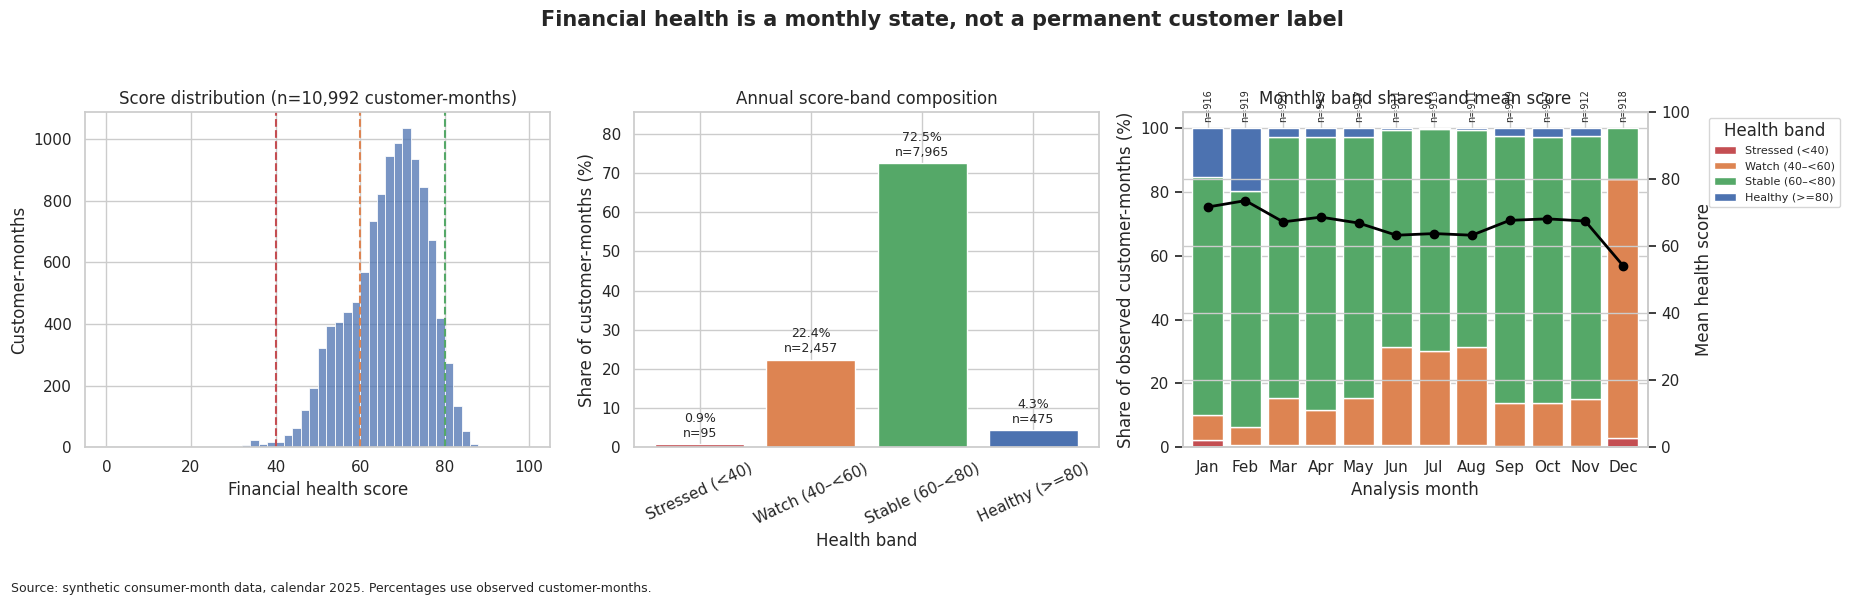

In [6]:
sns.set_theme(style="whitegrid", context="notebook")
band_colors = ["#c44e52", "#dd8452", "#55a868", "#4c72b0"]
figure, axes = plt.subplots(1, 3, figsize=(19, 6))

sns.histplot(monthly_data, x="financial_health_score", bins=np.arange(0, 102, 2), color="#4c72b0", ax=axes[0])
for threshold, color in zip([40, 60, 80], band_colors[:3]):
    axes[0].axvline(threshold, color=color, linestyle="--", linewidth=1.5)
axes[0].set(title=f"Score distribution (n={len(monthly_data):,} customer-months)", xlabel="Financial health score", ylabel="Customer-months")

band_plot = axes[1].bar(band_summary.index, band_summary["share_pct"], color=band_colors)
axes[1].bar_label(
    band_plot,
    labels=[f"{row.share_pct:.1f}%\nn={row.customer_months:,.0f}" for row in band_summary.itertuples()],
    padding=3,
    fontsize=9,
)
axes[1].set(title="Annual score-band composition", xlabel="Health band", ylabel="Share of customer-months (%)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylim(0, max(5, band_summary["share_pct"].max() * 1.18))

monthly_band_shares.plot(kind="bar", stacked=True, color=band_colors, width=0.82, ax=axes[2])
axes[2].set(title="Monthly band shares and mean score", xlabel="Analysis month", ylabel="Share of observed customer-months (%)")
axes[2].set_xticklabels(monthly_band_shares.index.strftime("%b"), rotation=0)
axes[2].legend(title="Health band", loc="upper left", bbox_to_anchor=(1.12, 1.0), fontsize=8)
score_axis = axes[2].twinx()
score_axis.plot(range(len(monthly_health_summary)), monthly_health_summary["mean_health_score"], color="black", marker="o", linewidth=2, label="Mean score")
score_axis.set_ylabel("Mean health score")
score_axis.set_ylim(0, 100)
for position, row in enumerate(monthly_health_summary.itertuples()):
    axes[2].text(position, 102, f"n={row.customer_months:,}", ha="center", va="bottom", fontsize=7, rotation=90, clip_on=False)

figure.suptitle("Financial health is a monthly state, not a permanent customer label", fontsize=15, fontweight="bold")
figure.text(0.01, 0.01, "Source: synthetic consumer-month data, calendar 2025. Percentages use observed customer-months.", fontsize=9)
figure.tight_layout(rect=[0, 0.05, 0.98, 0.94])
figure.savefig(figure_directory / "health_distribution.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(figure)


**Figure interpretation — distribution and trajectory.** The left panel shows the full 10,992-row distribution; the middle panel reports exact annual counts and shares for each reproducible band; and the right panel prevents the annual mix from being mistaken for a current state by showing month-specific composition, mean score, and each month's denominator. December has 918 observed customer-months and no `>=80` health observations in this dataset, so its visible shift should be described as a December pattern—not as permanent deterioration for all 999 historical consumers. The score construction is unpublished, and all records are synthetic; the chart is descriptive and cannot support causal or credit decisions. Source: `consumer_financial_health_engagement_2025.csv`.


## 4. Ratio factors associated with stressed health

The comparison uses medians because the ratios are not assumed normal. The stressed (`<40`) and healthy (`>=80`) contrast is summarized with a rank-biserial effect size: positive values mean a randomly selected stressed customer-month tends to have a higher ratio; negative values mean it tends to have a lower ratio. Month-stratified median differences reduce confounding by the strong month pattern but still describe association, not an independent causal effect.


In [7]:
association_metrics = {
    "spend_to_income_ratio": "Spend / income",
    "credit_utilization_ratio": "Credit utilization",
    "essential_spend_ratio": "Essential share",
    "spending_volatility": "Spending volatility",
}
band_medians = monthly_data.groupby("health_band", observed=True)[list(association_metrics)].median().reindex(health_band_order)
effect_rows = []
for metric, label in association_metrics.items():
    stressed_values = monthly_data.loc[monthly_data["financial_health_score"].lt(40), metric].reset_index(drop=True)
    healthy_values = monthly_data.loc[monthly_data["financial_health_score"].ge(80), metric].reset_index(drop=True)
    if stressed_values.empty or healthy_values.empty:
        raise ValueError(f"Both stressed and healthy observations are required for {metric}.")
    combined_values = pd.concat([stressed_values, healthy_values], ignore_index=True)
    stressed_rank_sum = combined_values.rank(method="average").iloc[: len(stressed_values)].sum()
    mann_whitney_u = stressed_rank_sum - len(stressed_values) * (len(stressed_values) + 1) / 2
    rank_biserial = 2 * mann_whitney_u / (len(stressed_values) * len(healthy_values)) - 1
    effect_rows.append(
        {
            "metric": label,
            "stressed_n": len(stressed_values),
            "healthy_n": len(healthy_values),
            "stressed_median": stressed_values.median(),
            "healthy_median": healthy_values.median(),
            "median_difference": stressed_values.median() - healthy_values.median(),
            "rank_biserial": rank_biserial,
        }
    )
association_effects = pd.DataFrame(effect_rows).set_index("metric")

month_difference_rows = []
for analysis_month, month_rows in monthly_data.groupby("analysis_month"):
    for metric, label in association_metrics.items():
        stressed_month_values = month_rows.loc[month_rows["financial_health_score"].lt(40), metric]
        healthy_month_values = month_rows.loc[month_rows["financial_health_score"].ge(80), metric]
        month_difference_rows.append(
            {
                "analysis_month": analysis_month,
                "metric": label,
                "median_difference": stressed_month_values.median() - healthy_month_values.median() if not stressed_month_values.empty and not healthy_month_values.empty else np.nan,
                "stressed_n": len(stressed_month_values),
                "healthy_n": len(healthy_month_values),
            }
        )
month_stratified_differences = pd.DataFrame(month_difference_rows)
display(association_effects.style.format({
    "stressed_n": "{:,.0f}", "healthy_n": "{:,.0f}",
    "stressed_median": "{:.3f}", "healthy_median": "{:.3f}",
    "median_difference": "{:+.3f}", "rank_biserial": "{:+.3f}",
}))


,stressed_n,healthy_n,stressed_median,healthy_median,median_difference,rank_biserial
metric,,,,,,
Spend / income,95,475,1.967,0.289,+1.679,+1.000
Credit utilization,95,475,0.552,0.076,+0.477,+1.000
Essential share,95,475,0.282,0.616,-0.334,-0.951
Spending volatility,95,475,2.042,0.999,+1.042,+0.968


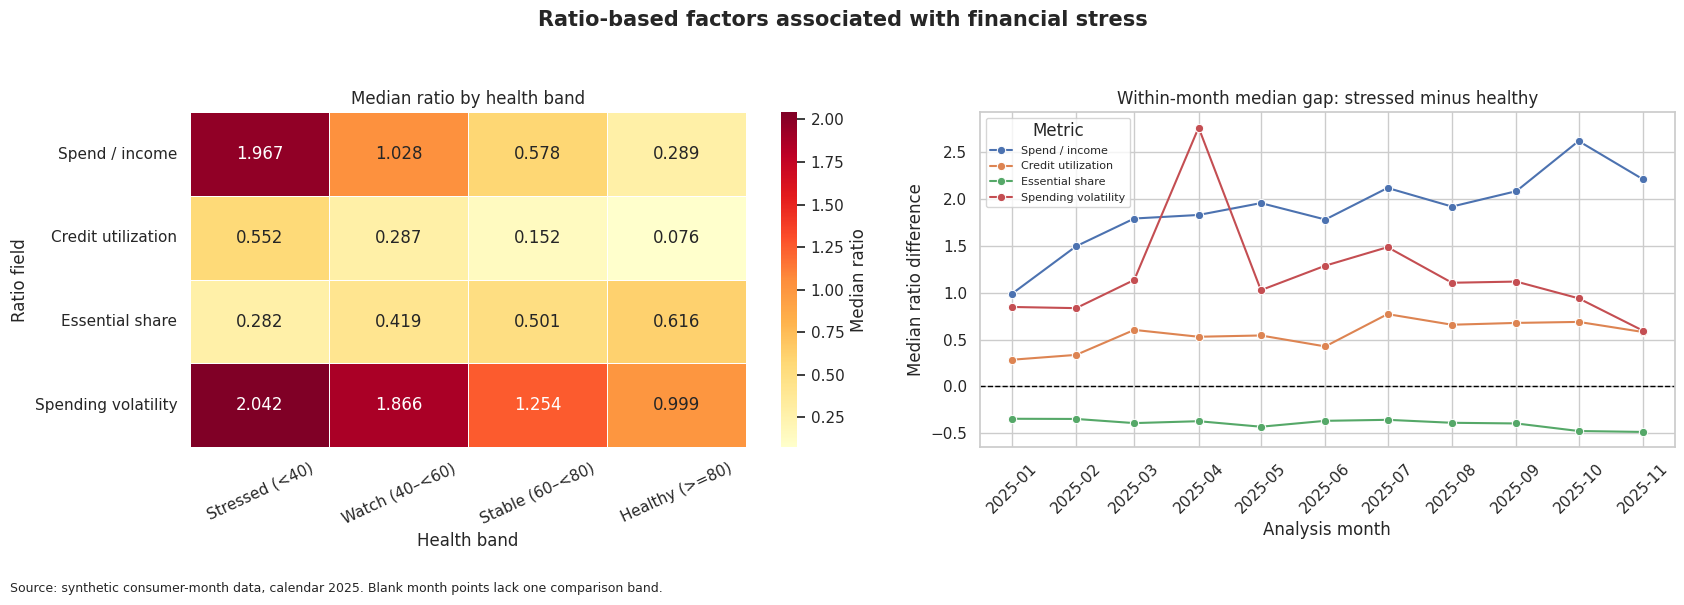

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(17, 6))
heatmap_values = band_medians.rename(columns=association_metrics).T
sns.heatmap(heatmap_values, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5, ax=axes[0], cbar_kws={"label": "Median ratio"})
axes[0].set(title="Median ratio by health band", xlabel="Health band", ylabel="Ratio field")
axes[0].tick_params(axis="x", rotation=25)

sns.lineplot(
    data=month_stratified_differences,
    x="analysis_month",
    y="median_difference",
    hue="metric",
    marker="o",
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set(title="Within-month median gap: stressed minus healthy", xlabel="Analysis month", ylabel="Median ratio difference")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Metric", fontsize=8)

figure.suptitle("Ratio-based factors associated with financial stress", fontsize=15, fontweight="bold")
figure.text(0.01, 0.01, "Source: synthetic consumer-month data, calendar 2025. Blank month points lack one comparison band.", fontsize=9)
figure.tight_layout(rect=[0, 0.05, 1, 0.94])
figure.savefig(figure_directory / "health_associations.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(figure)


**Figure interpretation — associated ratios.** The annotated heatmap supplies the annual consumer-month medians for all four bands, while the right panel checks whether the stressed–healthy median gap has the same direction within calendar months. The effect table above adds exact stressed and healthy sample sizes and a distribution-wide rank-biserial contrast rather than relying on raw VND rankings. A missing point means that month lacks stressed or healthy observations—most visibly, December has no healthy (`>=80`) comparator—so it is not imputed as zero. These fields may overlap with the unpublished score formula; therefore even a large, consistent gap is an association, not proof that the ratio independently causes low health. The dictionary defines volatility only as a coefficient of variation and does not publish its calculation window, so it must not be described as month-to-month volatility. Source: consumer-month file and data dictionary.


## 5. Differences by age, province, and occupation

These comparisons use one record per distinct historical consumer: mean health across that person's observed months, latest observed age, and stable province/occupation. This prevents a 12-month customer from receiving twelve times the weight of a short-history customer. Age cohorts are `<25`, `25–34`, `35–44`, `45–54`, `55–64`, and `65+`. Province results show all observed provinces. Because the occupation field is extremely granular, the chart shows only occupations with at least five distinct consumers and discloses how much population that filter covers; excluded rows remain in all other analyses.


In [9]:
stable_attribute_counts = monthly_data.groupby("consumer_id")[["occupation", "province_city"]].nunique()
if stable_attribute_counts.gt(1).any().any():
    inconsistent_attributes = stable_attribute_counts.columns[stable_attribute_counts.gt(1).any()].tolist()
    raise ValueError(f"Consumer profile attributes change across months: {inconsistent_attributes}")

customer_profiles = monthly_data.groupby("consumer_id").agg(
    mean_health_score=("financial_health_score", "mean"),
    age=("age", "max"),
    occupation=("occupation", "first"),
    province_city=("province_city", "first"),
    observed_months=("analysis_month", "size"),
).reset_index()
customer_profiles["age_cohort"] = pd.cut(
    customer_profiles["age"],
    bins=[-np.inf, 25, 35, 45, 55, 65, np.inf],
    labels=["<25", "25–34", "35–44", "45–54", "55–64", "65+"],
    right=False,
)

age_profiles = customer_profiles.groupby("age_cohort", observed=True)["mean_health_score"].agg(["mean", "median", "std", "count"])
province_profiles = customer_profiles.groupby("province_city")["mean_health_score"].agg(["mean", "median", "std", "count"]).sort_values("mean")
occupation_profiles_all = customer_profiles.groupby("occupation")["mean_health_score"].agg(["mean", "median", "std", "count"]).sort_values("mean")
occupation_minimum_customers = 5
occupation_profiles_eligible = occupation_profiles_all.loc[occupation_profiles_all["count"].ge(occupation_minimum_customers)]
occupation_profiles_display = pd.concat([occupation_profiles_eligible.head(6), occupation_profiles_eligible.tail(6)]).drop_duplicates().sort_values("mean")
for profile_table in [age_profiles, province_profiles, occupation_profiles_display]:
    profile_table["standard_error"] = profile_table["std"].fillna(0) / np.sqrt(profile_table["count"])
    profile_table["ci95"] = 1.96 * profile_table["standard_error"]

occupation_coverage = pd.DataFrame(
    {
        "value": [
            len(occupation_profiles_all),
            int(occupation_profiles_all["count"].lt(occupation_minimum_customers).sum()),
            int(occupation_profiles_eligible["count"].sum()),
            100 * occupation_profiles_eligible["count"].sum() / len(customer_profiles),
        ]
    },
    index=["distinct occupations", "occupations below n=5", "consumers represented by eligible occupations", "population coverage of eligible occupations (%)"],
)
display(age_profiles[["mean", "median", "count"]].style.format({"mean": "{:.1f}", "median": "{:.1f}", "count": "{:,.0f}"}))
display(occupation_coverage.style.format({"value": "{:,.1f}"}))


,mean,median,count
age_cohort,,,
<25,65.8,65.9,69
25–34,65.8,65.5,177
35–44,66.4,66.0,165
45–54,66.0,66.1,198
55–64,67.0,67.2,175
65+,66.6,66.7,215


,value
distinct occupations,396.0
occupations below n=5,346.0
consumers represented by eligible occupations,287.0
population coverage of eligible occupations (%),28.7


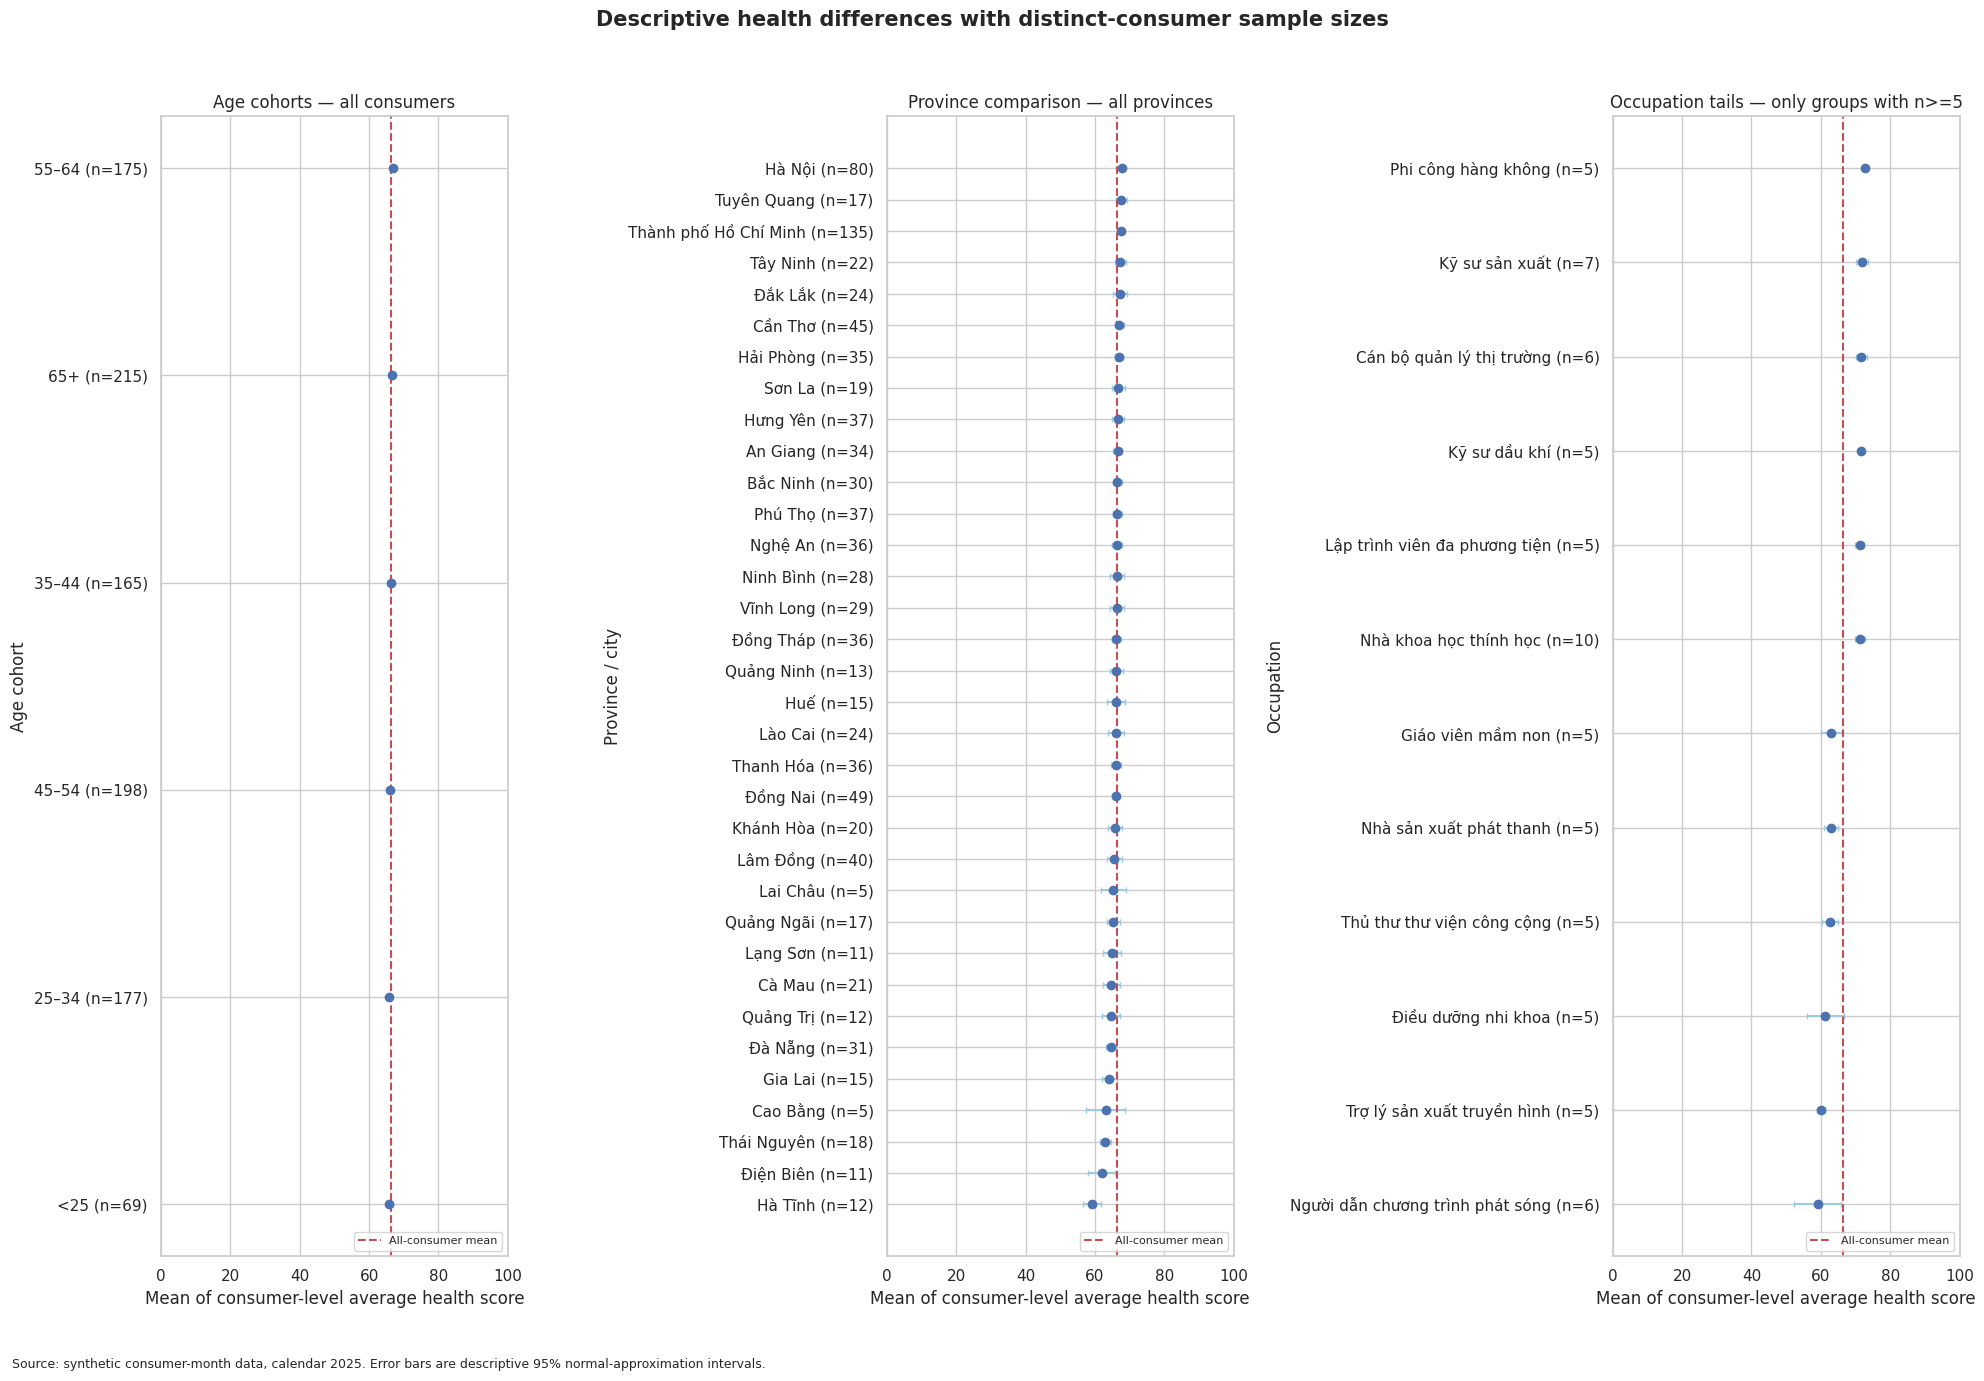

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(20, 14))
demographic_panels = [
    (age_profiles.sort_values("mean"), "Age cohort", "Age cohorts — all consumers"),
    (province_profiles, "Province / city", "Province comparison — all provinces"),
    (occupation_profiles_display, "Occupation", "Occupation tails — only groups with n>=5"),
]
for axis, (profile_table, y_label, title) in zip(axes, demographic_panels):
    positions = np.arange(len(profile_table))
    axis.errorbar(profile_table["mean"], positions, xerr=profile_table["ci95"], fmt="o", color="#4c72b0", ecolor="#9ecae1", capsize=2)
    axis.set_yticks(positions, [f"{index} (n={int(row['count'])})" for index, row in profile_table.iterrows()])
    axis.axvline(customer_profiles["mean_health_score"].mean(), color="#c44e52", linestyle="--", linewidth=1.5, label="All-consumer mean")
    axis.set(title=title, xlabel="Mean of consumer-level average health score", ylabel=y_label, xlim=(0, 100))
    axis.legend(loc="lower right", fontsize=8)

figure.suptitle("Descriptive health differences with distinct-consumer sample sizes", fontsize=15, fontweight="bold")
figure.text(0.01, 0.01, "Source: synthetic consumer-month data, calendar 2025. Error bars are descriptive 95% normal-approximation intervals.", fontsize=9)
figure.tight_layout(rect=[0, 0.04, 1, 0.96])
figure.savefig(figure_directory / "demographic_profiles.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(figure)


**Figure interpretation — demographic profiles.** Each point is the mean of distinct consumers' own observed-month averages, the dashed line is the 999-consumer benchmark, and every label exposes its `n`. This makes the age, province, and occupation contrasts comparable without over-weighting complete histories. The occupation tails are a transparent descriptive screen, not a full-population league table: occupations below five consumers are omitted from that panel because their apparent extremes are unstable, while the coverage table above quantifies the omission. Province identities and all financial records are synthetic, age/occupation/province may proxy unobserved differences, and overlapping intervals caution against strong ordering. These comparisons do not establish demographic causes and must not be used for adverse or credit decisions. Source: consumer-month file and data dictionary.


## 6. Financially stressed but highly engaged crossover

The primary reproducible rule is `financial_health_score < 40` **and** `engagement_score >= 80`, matching the original very-high engagement band. A pre-declared sensitivity rule lowers only engagement to `>=70`. Results distinguish: (1) matching 2025 customer-months, (2) distinct historical consumers with at least one match, and (3) matching rows among the separately reported December-observed population. A person with one matching month is not labelled permanently stressed.


In [11]:
december_month = pd.Timestamp("2025-12-01")
december_data = monthly_data.loc[monthly_data["analysis_month"].eq(december_month)]
if december_data.empty:
    raise ValueError("December 2025 is required for the separate snapshot.")

engagement_cutoffs = {"Primary: engagement >=80": 80, "Sensitivity: engagement >=70": 70}
crossover_flags = {}
crossover_summary_rows = []
for rule_label, engagement_cutoff in engagement_cutoffs.items():
    match_flag = monthly_data["financial_health_score"].lt(40) & monthly_data["engagement_score"].ge(engagement_cutoff)
    crossover_flags[rule_label] = match_flag
    december_match_flag = december_data["financial_health_score"].lt(40) & december_data["engagement_score"].ge(engagement_cutoff)
    crossover_summary_rows.append(
        {
            "rule": rule_label,
            "engagement_cutoff": engagement_cutoff,
            "year_customer_months": int(match_flag.sum()),
            "year_customer_month_share_pct": 100 * match_flag.mean(),
            "distinct_historical_consumers": monthly_data.loc[match_flag, "consumer_id"].nunique(),
            "historical_consumer_share_pct": 100 * monthly_data.loc[match_flag, "consumer_id"].nunique() / monthly_data["consumer_id"].nunique(),
            "december_matches": int(december_match_flag.sum()),
            "december_observed_denominator": len(december_data),
            "december_match_share_pct": 100 * december_match_flag.mean(),
        }
    )
crossover_summary = pd.DataFrame(crossover_summary_rows).set_index("rule")

profile_metrics = {
    "spend_to_income_ratio": "Spend / income",
    "credit_utilization_ratio": "Credit utilization",
    "essential_spend_ratio": "Essential share",
    "spending_volatility": "Spending volatility",
    "category_diversity": "Category diversity",
    "online_spend_ratio": "Online spend share",
}
profile_groups = {
    "All customer-months": pd.Series(True, index=monthly_data.index),
    "All stressed (<40)": monthly_data["financial_health_score"].lt(40),
    "Stressed + engagement >=80": crossover_flags["Primary: engagement >=80"],
    "Stressed + engagement >=70": crossover_flags["Sensitivity: engagement >=70"],
}
crossover_profile_medians = pd.DataFrame(
    {group_label: monthly_data.loc[group_flag, list(profile_metrics)].median() for group_label, group_flag in profile_groups.items()}
).rename(index=profile_metrics)
crossover_profile_counts = pd.Series({group_label: int(group_flag.sum()) for group_label, group_flag in profile_groups.items()}, name="customer_months")

persistence_rows = []
persistence_bucket_rows = []
for rule_label, match_flag in crossover_flags.items():
    match_counts = match_flag.groupby(monthly_data["consumer_id"]).sum().rename("matching_months")
    rule_history = consumer_history.join(match_counts).fillna({"matching_months": 0})
    rule_history = rule_history.loc[rule_history["matching_months"].gt(0)].copy()
    rule_history["matching_share_of_observed_months"] = rule_history["matching_months"] / rule_history["observed_months"]
    persistence_rows.append(
        {
            "rule": rule_label,
            "distinct_consumers": len(rule_history),
            "median_observed_months": rule_history["observed_months"].median(),
            "median_matching_months": rule_history["matching_months"].median(),
            "repeat_match_consumers": int(rule_history["matching_months"].ge(2).sum()),
            "short_history_consumers_1_or_2_months": int(rule_history["observed_months"].le(2).sum()),
            "median_matching_share_pct": 100 * rule_history["matching_share_of_observed_months"].median(),
        }
    )
    persistence_buckets = pd.cut(rule_history["matching_months"], bins=[0, 1, 2, np.inf], labels=["1 month", "2 months", "3+ months"])
    bucket_counts = persistence_buckets.value_counts(sort=False)
    for bucket_label, bucket_count in bucket_counts.items():
        persistence_bucket_rows.append(
            {"rule": rule_label, "persistence": bucket_label, "consumers": int(bucket_count), "share_pct": 100 * bucket_count / len(rule_history)}
        )
crossover_persistence = pd.DataFrame(persistence_rows).set_index("rule")
persistence_buckets = pd.DataFrame(persistence_bucket_rows)

display(crossover_summary.style.format({
    "engagement_cutoff": "{:.0f}", "year_customer_months": "{:,.0f}",
    "year_customer_month_share_pct": "{:.2f}%", "distinct_historical_consumers": "{:,.0f}",
    "historical_consumer_share_pct": "{:.2f}%", "december_matches": "{:,.0f}",
    "december_observed_denominator": "{:,.0f}", "december_match_share_pct": "{:.2f}%",
}))
display(crossover_profile_medians.style.format("{:.3f}"))
display(crossover_profile_counts.to_frame().style.format("{:,.0f}"))
display(crossover_persistence.style.format({
    "distinct_consumers": "{:,.0f}", "median_observed_months": "{:.1f}",
    "median_matching_months": "{:.1f}", "repeat_match_consumers": "{:,.0f}",
    "short_history_consumers_1_or_2_months": "{:,.0f}", "median_matching_share_pct": "{:.1f}%",
}))


,engagement_cutoff,year_customer_months,year_customer_month_share_pct,distinct_historical_consumers,historical_consumer_share_pct,december_matches,december_observed_denominator,december_match_share_pct
rule,,,,,,,,
Primary: engagement >=80,80,52,0.47%,45,4.50%,8,918,0.87%
Sensitivity: engagement >=70,70,81,0.74%,64,6.41%,25,918,2.72%


,All customer-months,All stressed (<40),Stressed + engagement >=80,Stressed + engagement >=70
Spend / income,0.632,1.967,1.844,1.967
Credit utilization,0.169,0.552,0.526,0.552
Essential share,0.485,0.282,0.280,0.294
Spending volatility,1.331,2.042,1.853,1.910
Category diversity,14.000,14.000,14.000,14.000
Online spend share,0.192,0.325,0.466,0.359


,customer_months
All customer-months,"10,992"
All stressed (<40),95
Stressed + engagement >=80,52
Stressed + engagement >=70,81


,distinct_consumers,median_observed_months,median_matching_months,repeat_match_consumers,short_history_consumers_1_or_2_months,median_matching_share_pct
rule,,,,,,
Primary: engagement >=80,45,12.0,1.0,6,0,8.3%
Sensitivity: engagement >=70,64,12.0,1.0,14,0,8.3%


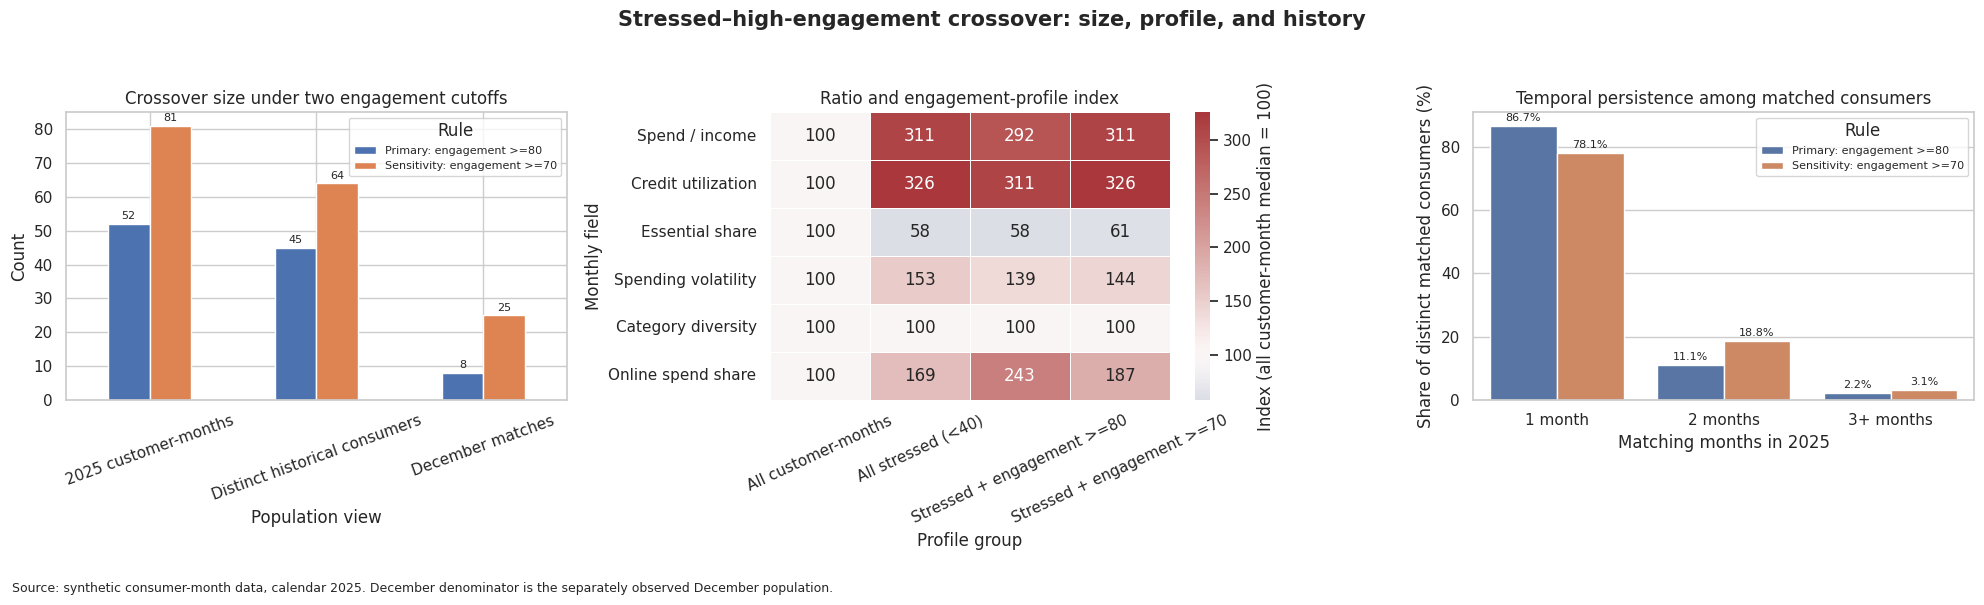

In [12]:
figure, axes = plt.subplots(1, 3, figsize=(20, 6))
count_columns = ["year_customer_months", "distinct_historical_consumers", "december_matches"]
count_labels = ["2025 customer-months", "Distinct historical consumers", "December matches"]
crossover_counts_plot = crossover_summary[count_columns].copy()
crossover_counts_plot.columns = count_labels
crossover_counts_plot.T.plot(kind="bar", color=["#4c72b0", "#dd8452"], ax=axes[0])
axes[0].set(title="Crossover size under two engagement cutoffs", xlabel="Population view", ylabel="Count")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Rule", fontsize=8)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="{:,.0f}", padding=2, fontsize=8)

profile_index = crossover_profile_medians.div(crossover_profile_medians["All customer-months"], axis=0).mul(100)
sns.heatmap(profile_index, annot=True, fmt=".0f", center=100, cmap="vlag", linewidths=0.5, ax=axes[1], cbar_kws={"label": "Index (all customer-month median = 100)"})
axes[1].set(title="Ratio and engagement-profile index", xlabel="Profile group", ylabel="Monthly field")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=persistence_buckets, x="persistence", y="share_pct", hue="rule", palette=["#4c72b0", "#dd8452"], ax=axes[2])
axes[2].set(title="Temporal persistence among matched consumers", xlabel="Matching months in 2025", ylabel="Share of distinct matched consumers (%)")
axes[2].legend(title="Rule", fontsize=8)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)

figure.suptitle("Stressed–high-engagement crossover: size, profile, and history", fontsize=15, fontweight="bold")
figure.text(0.01, 0.01, "Source: synthetic consumer-month data, calendar 2025. December denominator is the separately observed December population.", fontsize=9)
figure.tight_layout(rect=[0, 0.05, 1, 0.94])
figure.savefig(figure_directory / "stressed_engaged.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(figure)


**Figure interpretation — crossover.** The first panel prevents three different denominators from being conflated: annual matching customer-months out of 10,992, distinct ever-matching historical consumers out of 999, and December matches out of the 918 consumers observed that month. Lowering engagement from `>=80` to `>=70` is shown as sensitivity, not as a redefinition chosen to enlarge the segment; in the intended source the looser December rule identifies 25 rows. The middle panel profiles spend-to-income, utilization, essential share, documented volatility, category diversity, and online-spend share against an all-customer-month median index of 100; the raw medians and group `n` remain visible in the tables above. The persistence panel distinguishes one-month crossings from repeated crossings, while the history table exposes short observation windows. These are historical analytical signals, not proof of current distress, contactability, causation, or credit risk. Source: consumer-month file and data dictionary.


## 7. Task 2 synthesis and unresolved limitations

1. **Distribution:** health is reported as a consumer-month state with exact band counts, monthly denominators, and a separate December view; it is not converted into a permanent customer label.
2. **Associated factors:** stressed-versus-healthy comparisons use ratio medians, a rank-based effect size, and within-month gaps. They are associations because the unpublished score formula may incorporate the same ratios.
3. **Demographics:** age, province, and occupation are compared at a one-consumer grain with visible sample sizes. Sparse occupations are not presented as robust business rankings, and synthetic demographics cannot justify adverse treatment.
4. **Crossover:** the primary `health<40 & engagement>=80` rule and `>=70` sensitivity separately report annual customer-months, ever-matching historical consumers, December-observed matches, ratio/digital/category profiles, and persistence. Supportive analysis is appropriate; punitive or credit decisions are prohibited.

**Unresolved data limitations.** The financial-health-score construction and the calculation window for `spending_volatility` are not published. Synthetic income, credit, balances, identities, and geography are not realistic financial records. Partial observation histories create unequal opportunities to cross a threshold. The monthly aggregate supports online-spend share and category diversity but not named-merchant, day/hour, or detailed channel claims; because none is needed for Task 2, the raw transaction file was deliberately not scanned.
